In [ ]:
# Step 1: Importing Required Libraries

import pandas as pd                          # For data manipulation
import numpy as np                           # For numerical analysis
import matplotlib.pyplot as plt              # For data visualization (plotting graphs)
import seaborn as sns                        # For data visualization

from sklearn.metrics import accuracy_score   # For finding accuracy in classification problems
from sklearn.metrics import confusion_matrix # For measuring ML algorithm performance
from sklearn.model_selection import train_test_split  # For splitting data into train & test sets
from sklearn.preprocessing import StandardScaler      # For feature scaling / normalizing data

import joblib                                # For serializing ML models and saving to file

In [ ]:
# Step 2: Loading the Dataset

import os
import cv2
from zipfile import ZipFile

# Extract the zip file
with ZipFile('subset_499.zip', 'r') as zip_ref:
    zip_ref.extractall('malaria_dataset')

# Define paths
parasitized_path = 'malaria_dataset/Parasitized/'
uninfected_path = 'malaria_dataset/Uninfected/'

# Image size to resize all images to
IMG_SIZE = 64  # 64x64 pixels

# Lists to store images and labels
data = []
labels = []

# Loading Parasitized images (label = 1, meaning infected)
for img_name in os.listdir(parasitized_path):
    img_path = os.path.join(parasitized_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(1)   # 1 = Parasitized (infected)

# Loading Uninfected images (label = 0, meaning healthy)
for img_name in os.listdir(uninfected_path):
    img_path = os.path.join(uninfected_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(0)   # 0 = Uninfected (healthy)

# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

print("Dataset shape:", data.shape)       # Should be (998, 64, 64, 3)
print("Labels shape:", labels.shape)      # Should be (998,)
print("Total Images Loaded:", len(data))


Dataset shape: (998, 64, 64, 3)
Labels shape: (998,)
Total Images Loaded: 998


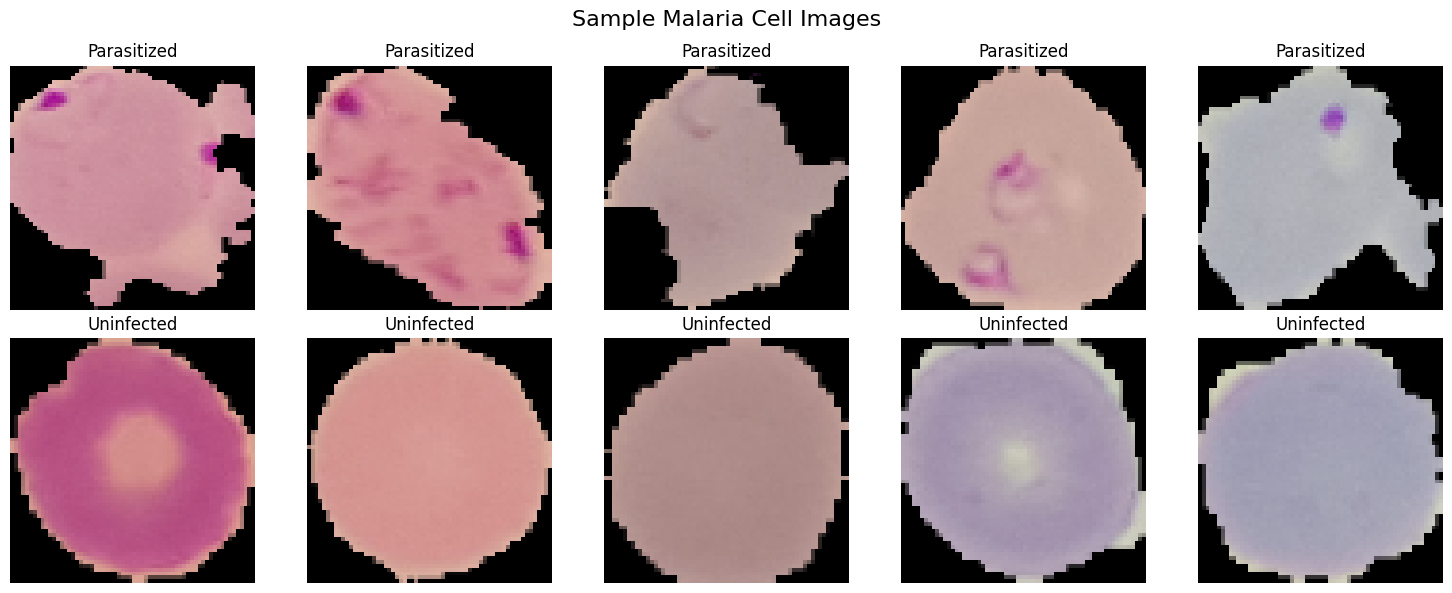

/tmp/ipython-input-350/3971968910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='Set2')


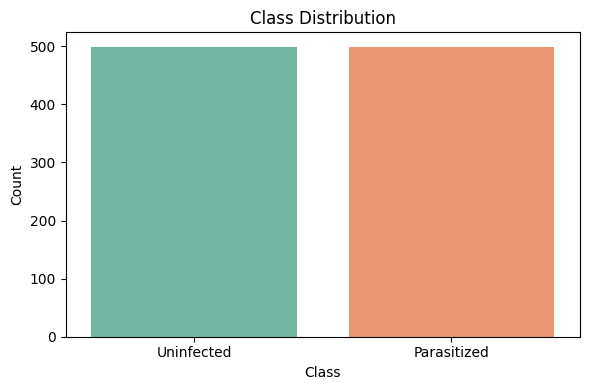

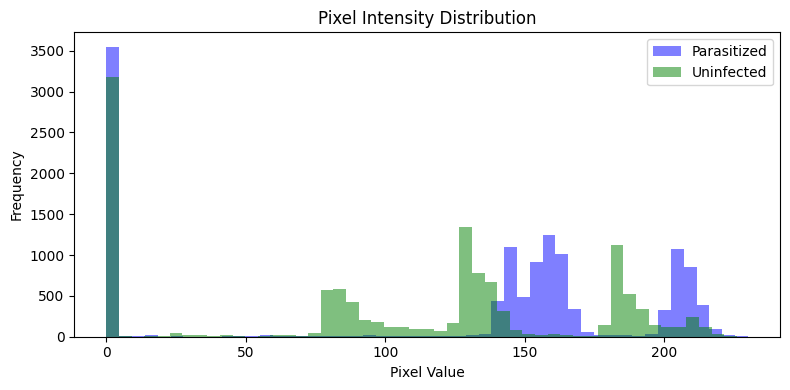

In [ ]:
# Step 3: Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────────
# 3.1 Show Sample Images from Dataset
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Malaria Cell Images', fontsize=16)

# Show 5 Parasitized samples
for i in range(5):
    axes[0, i].imshow(cv2.cvtColor(data[i], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title('Parasitized')
    axes[0, i].axis('off')

# Show 5 Uninfected samples
for i in range(5):
    axes[1, i].imshow(cv2.cvtColor(data[499 + i], cv2.COLOR_BGR2RGB))
    axes[1, i].set_title('Uninfected')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3.2 Class Distribution Bar Chart
# ─────────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x=labels, palette='Set2')
plt.xticks([0, 1], ['Uninfected', 'Parasitized'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3.3 Pixel Intensity Distribution
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(data[0].ravel(), bins=50, color='blue', alpha=0.5, label='Parasitized')
plt.hist(data[499].ravel(), bins=50, color='green', alpha=0.5, label='Uninfected')
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3.4 Plot Training History (Accuracy & Loss)
# ─────────────────────────────────────────────
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Call this after training each model like:
# plot_training_history(history, 'CustomCNN')
# plot_training_history(history, 'MobileNetV2')
# plot_training_history(history, 'EfficientNetB0')

# ─────────────────────────────────────────────
# 3.5 Confusion Matrix
# ─────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred,
          target_names=['Uninfected', 'Parasitized']))

# ─────────────────────────────────────────────
# 3.6 Model Comparison Bar Chart
# ─────────────────────────────────────────────
def plot_model_comparison(results):
    models = list(results.keys())
    val_accuracies = [results[m]['val_accuracy'] for m in models]
    roc_aucs = [results[m]['roc_auc'] for m in models]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, val_accuracies, width, label='Val Accuracy', color='steelblue')
    bars2 = ax.bar(x + width/2, roc_aucs, width, label='ROC AUC', color='orange')

    ax.set_title('Model Comparison')
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.set_ylim(0, 1.1)

    # Add value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Call after all models trained:
# plot_model_comparison(results)

Train size: (638, 64, 64, 3)
Val size: (160, 64, 64, 3)
Test size: (200, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipython-input-350/1478262542.py:83: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

CustomCNN Summary:


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Non-trainable params: 448 (1.75 KB)


Training CustomCNN
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.5410 - loss: 2.5979 - precision: 0.5702 - recall: 0.5815
Epoch 1: val_accuracy improved from -inf to 0.53750, saving model to CustomCNN_best.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 470ms/step - accuracy: 0.5423 - loss: 2.5687 - precision: 0.5704 - recall: 0.5823 - val_accuracy: 0.5375 - val_loss: 0.6998 - val_precision: 0.5278 - val_recall: 0.4872 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6301 - loss: 0.8593 - precision: 0.6430 - recall: 0.6534
Epoch 2: val_accuracy did not improve from 0.53750
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 336ms/step - accuracy: 0.6299 - loss: 0.8584 - precision: 0.6429 - recall: 0.6516 - val_accuracy: 0.5125 - val_loss: 1.6341 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.6211 - loss: 0.8126 - precision: 0.6397 - recall: 0.5362
Epoch 3: val_accuracy did not improve from 0.53750
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 433ms/step - accuracy: 0.6213 - loss: 0.8108 - precision: 0.6395 - recall: 0.5405 - val_accuracy: 0.5125 - val_loss: 2.1729 - val_precision: 0.0000e+00 - val_recall:

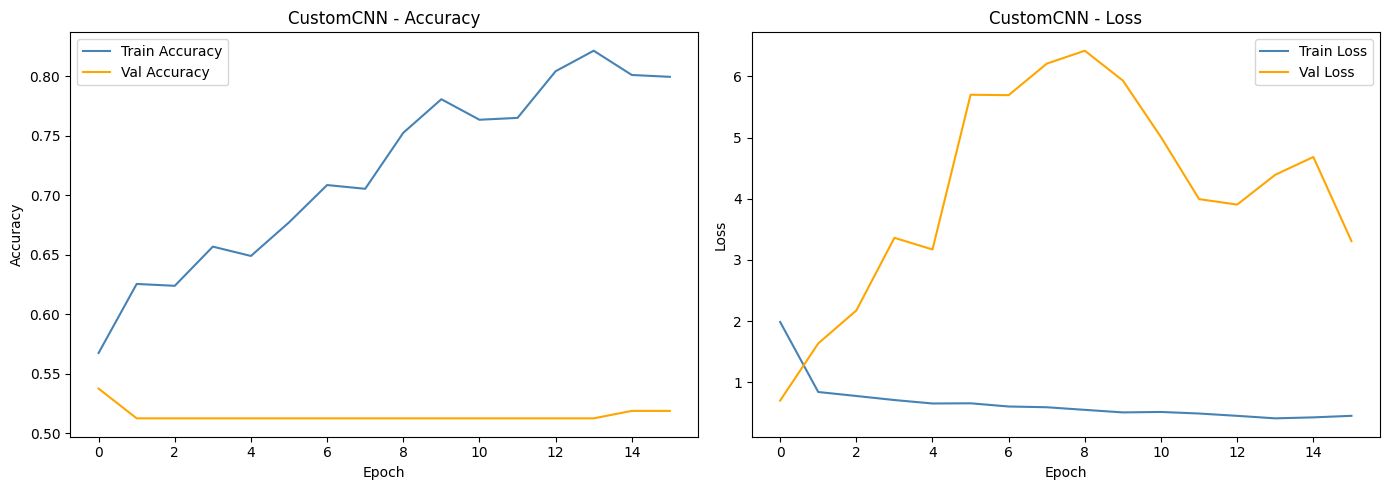

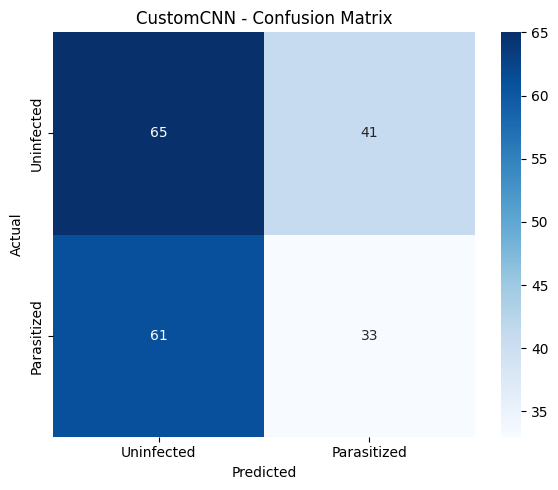


Classification Report for CustomCNN:
              precision    recall  f1-score   support

  Uninfected       0.52      0.61      0.56       106
 Parasitized       0.45      0.35      0.39        94

    accuracy                           0.49       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.49      0.48       200


MobileNetV2 Summary:


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Training MobileNetV2
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7191 - loss: 0.6048 - precision: 0.7247 - recall: 0.7232
Epoch 1: val_accuracy improved from -inf to 0.90625, saving model to MobileNetV2_best.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 282ms/step - accuracy: 0.7212 - loss: 0.6014 - precision: 0.7267 - recall: 0.7256 - val_accuracy: 0.9062 - val_loss: 0.2605 - val_precision: 0.9565 - val_recall: 0.8462 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8313 - loss: 0.4285 - precision: 0.8461 - recall: 0.8317
Epoch 2: val_accuracy did not improve from 0.90625
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.8326 - loss: 0.4263 - precision: 0.8475 - recall: 0.8323 - val_accuracy: 0.9000 - val_loss: 0.2712 - val_precision: 0.9559 - val_recall: 0.8333 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8696 - loss: 0.3174 - precision: 0.8831 - recall: 0.8397
Epoch 3: val_accuracy improved from 0.90625 to 0.91875, saving model to MobileNetV2_best.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step - accuracy: 0.8691 - loss: 0.3188 - precision: 0.8826 - recall: 0.8402 - val_accuracy: 0.9187 - val_loss: 0.2263 - val_precision: 0.9221 - val_recall: 0.9103 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8449 - loss: 0.3552 - precision: 0.8471 - recall: 0.8561
Epoch 4: val_accuracy did not improve from 0.91875
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.8450 - loss: 0.3548 - precision: 0.8471 - recall: 0.8559 - val_accuracy: 0.9187 - val_loss: 0.2412 - val_precision: 0.9577 - val_recall: 0.8718 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8438 - loss: 0.3700 - precision: 0.8646 - recall: 0.8332
Epoch 5: val_accuracy did not improve from 0.91875
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.8443 - loss: 0.3689 - precision: 0.8650 - recall: 0.8334 - val_accuracy: 0.9062 - val_loss: 0.2552 - val_precision: 0.9701 - val_recall: 0.8333 - lea

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.8886 - loss: 0.3113 - precision: 0.9291 - recall: 0.8484 - val_accuracy: 0.9312 - val_loss: 0.2204 - val_precision: 0.9589 - val_recall: 0.8974 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9059 - loss: 0.2582 - precision: 0.9266 - recall: 0.8914
Epoch 7: val_accuracy did not improve from 0.93125
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9054 - loss: 0.2593 - precision: 0.9264 - recall: 0.8903 - val_accuracy: 0.9250 - val_loss: 0.2201 - val_precision: 0.9342 - val_recall: 0.9103 - learning_rate: 0.0010
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8628 - loss: 0.2994 - precision: 0.8915 - recall: 0.8378
Epoch 8: val_accuracy did not improve from 0.93125
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.8628 - loss: 0.2992 - precision: 0.8914 - recall: 0.8376 - val_accuracy: 0.9187 - val_loss: 0.2183 - val_precision: 0.9452 - val_recall: 0.8846 - lea

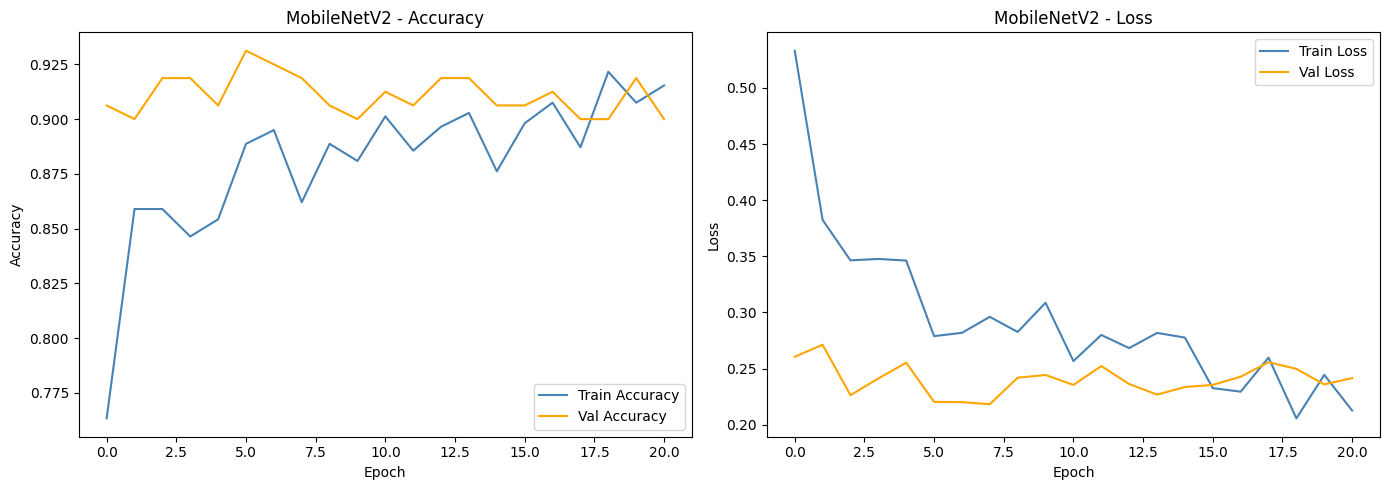

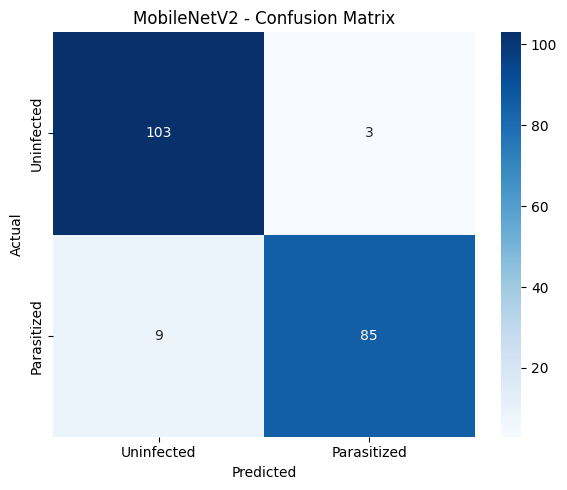


Classification Report for MobileNetV2:
              precision    recall  f1-score   support

  Uninfected       0.92      0.97      0.94       106
 Parasitized       0.97      0.90      0.93        94

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200


EfficientNetB0 Summary:


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input_layer_2[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 64, 64, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 64, 64, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 65, 65, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 32, 32,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 32, 32,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 32, 32,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 32, 32,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 32, 32,    │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Training EfficientNetB0
Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5378 - loss: 0.7888 - precision: 0.5388 - recall: 0.6124
Epoch 1: val_accuracy improved from -inf to 0.51250, saving model to EfficientNetB0_best.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 540ms/step - accuracy: 0.5369 - loss: 0.7874 - precision: 0.5384 - recall: 0.6082 - val_accuracy: 0.5125 - val_loss: 0.6967 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4836 - loss: 0.7308 - precision: 0.5061 - recall: 0.5119
Epoch 2: val_accuracy did not improve from 0.51250
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.4841 - loss: 0.7304 - precision: 0.5061 - recall: 0.5121 - val_accuracy: 0.4875 - val_loss: 0.6946 - val_precision: 0.4875 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.4950 - loss: 0.7015 - precision: 0.5056 - recall: 0.6331
Epoch 3: val_accuracy did not improve from 0.51250
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.4944 - loss: 0.7016 - precision: 0.5052 - recall: 0.6327 - val_accuracy: 0.4875 - val_loss: 0.6934 - val_precision: 0.4875 - val_recall: 1.0

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 662ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.53      1.00      0.69       106
 Parasitized       0.00      0.00      0.00        94

    accuracy                           0.53       200
   macro avg       0.27      0.50      0.35       200
weighted avg       0.28      0.53      0.37       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


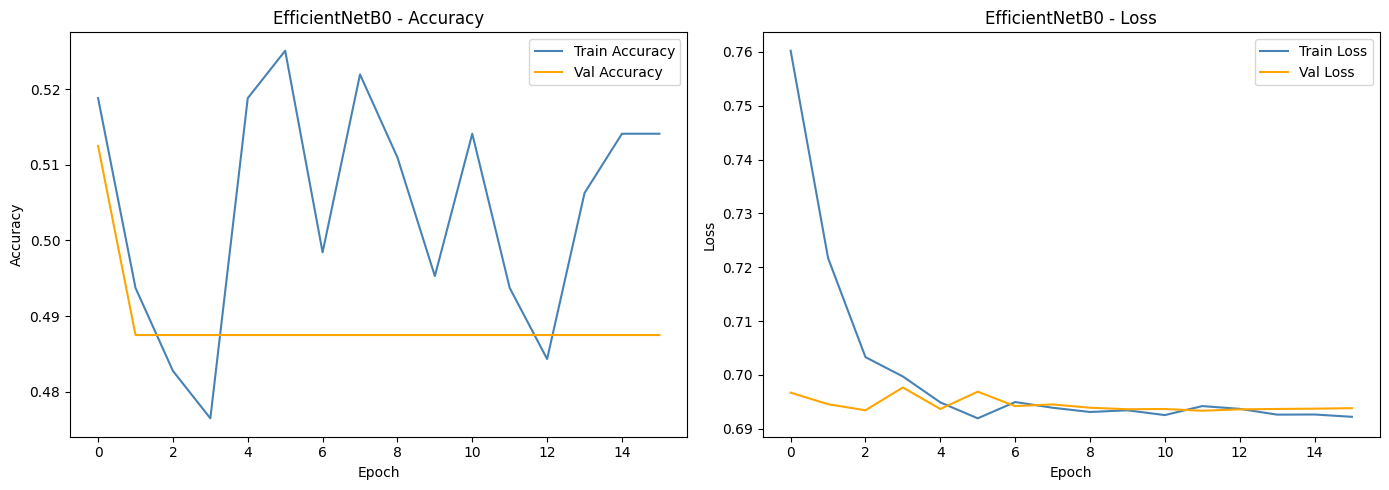

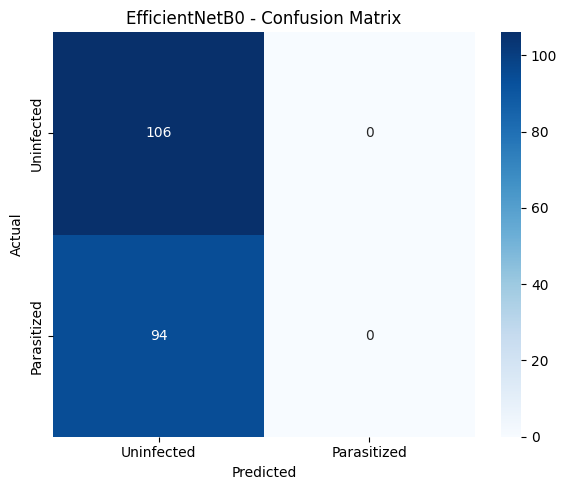


Classification Report for EfficientNetB0:
              precision    recall  f1-score   support

  Uninfected       0.53      1.00      0.69       106
 Parasitized       0.00      0.00      0.00        94

    accuracy                           0.53       200
   macro avg       0.27      0.50      0.35       200
weighted avg       0.28      0.53      0.37       200


MODEL COMPARISON

             Model  Validation Accuracy   ROC AUC
0       CustomCNN              0.53750  0.405460
1     MobileNetV2              0.93125  0.971397
2  EfficientNetB0              0.51250  0.511943

 Best Model: MobileNetV2
Validation Accuracy: 0.9312
ROC AUC: 0.9714


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


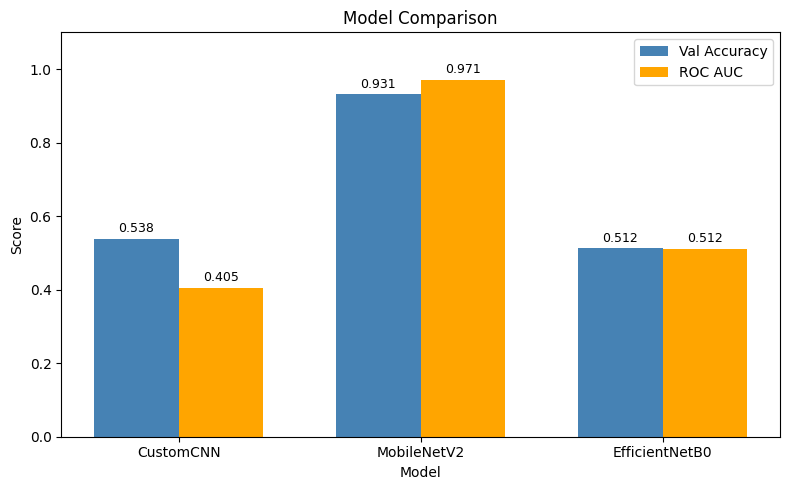

In [ ]:
# Step 4: Model Building & Training

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# ─────────────────────────────────────────────
# 4.1 Config / Hyperparameters
# ─────────────────────────────────────────────
class config:
    IMG_SIZE = 64
    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE = 0.001

# ─────────────────────────────────────────────
# 4.2 Normalize & Split Data
# ─────────────────────────────────────────────
# Normalize pixel values to 0-1
X = data / 255.0
y = labels

# Split into train, validation, test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                    test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

# ─────────────────────────────────────────────
# 4.3 Data Augmentation
# ─────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

train_gen = train_datagen.flow(X_train, y_train, batch_size=config.BATCH_SIZE)
val_gen   = ImageDataGenerator().flow(X_val, y_val, batch_size=config.BATCH_SIZE)

# ─────────────────────────────────────────────
# 4.4 Custom CNN Model
# ─────────────────────────────────────────────
def create_custom_cnn(img_size):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name='CustomCNN')
    return model

# ─────────────────────────────────────────────
# 4.5 Transfer Learning Model (MobileNetV2 / EfficientNetB0)
# ─────────────────────────────────────────────
def create_transfer_model(model_name, img_size):
    # Load base model without top layer
    if model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False,
                                  input_shape=(img_size, img_size, 3))
    elif model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet', include_top=False,
                                     input_shape=(img_size, img_size, 3))

    # Freeze base model layers
    base_model.trainable = False

    # Add custom top layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output, name=model_name)
    return model

# ─────────────────────────────────────────────
# 4.6 Train Function
# ─────────────────────────────────────────────
def train_model(model, model_name, train_gen, val_gen, epochs, learning_rate):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=1)
    ]

    # Train
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks
    )

    return history, model

# ─────────────────────────────────────────────
# 4.7 Train All 3 Models
# ─────────────────────────────────────────────
models_to_train = {
    'CustomCNN'    : create_custom_cnn(config.IMG_SIZE),
    'MobileNetV2'  : create_transfer_model('MobileNetV2', config.IMG_SIZE),
    'EfficientNetB0': create_transfer_model('EfficientNetB0', config.IMG_SIZE)
}

results = {}

for model_name, model in models_to_train.items():
    print(f"\n{model_name} Summary:")
    model.summary()

    # Train model
    history, trained_model = train_model(
        model, model_name, train_gen, val_gen,
        config.EPOCHS, config.LEARNING_RATE
    )

    # Evaluate on test set
    print(f"\n{'='*50}")
    print("MODEL EVALUATION")
    print(f"{'='*50}")

    y_pred_prob = trained_model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    val_accuracy = max(history.history['val_accuracy'])
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Uninfected', 'Parasitized']))

    # Save results
    results[model_name] = {
        'history'      : history,
        'model'        : trained_model,
        'val_accuracy' : val_accuracy,
        'roc_auc'      : roc_auc
    }

    # Plot accuracy & loss curves
    plot_training_history(history, model_name)
    plot_confusion_matrix(y_test, y_pred, model_name)

# ─────────────────────────────────────────────
# 4.8 Find Best Model
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

comparison_df = pd.DataFrame({
    'Model'               : list(results.keys()),
    'Validation Accuracy' : [results[m]['val_accuracy'] for m in results.keys()],
    'ROC AUC'             : [results[m]['roc_auc'] for m in results.keys()]
})

print("\n", comparison_df)

if not comparison_df.empty:
    best_model_name = comparison_df.loc[comparison_df['Validation Accuracy'].idxmax(), 'Model']
    print(f"\n Best Model: {best_model_name}")
    print(f"Validation Accuracy: {results[best_model_name]['val_accuracy']:.4f}")
    print(f"ROC AUC: {results[best_model_name]['roc_auc']:.4f}")

    # Plot final model comparison
    plot_model_comparison(results)

In [ ]:
# Step 5: Save the Best Model

import joblib

# ─────────────────────────────────────────────
# 5.1 Identify & Save Best Model
# ─────────────────────────────────────────────
best_model_name = comparison_df.loc[comparison_df['Validation Accuracy'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {results[best_model_name]['val_accuracy']:.4f}")
print(f"ROC AUC: {results[best_model_name]['roc_auc']:.4f}")

# Save in Keras format (.h5)
best_model.save(f'{best_model_name}_final.h5')
print(f"\n Model saved as '{best_model_name}_final.h5'")

# Save using Joblib as well (for sklearn compatibility)
joblib.dump(best_model, f'{best_model_name}_joblib.pkl')
print(f" Model also saved as '{best_model_name}_joblib.pkl'")

# ─────────────────────────────────────────────
# 5.2 Save the Scaler too (important for predictions)
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train.reshape(len(X_train), -1))
joblib.dump(scaler, 'scaler.pkl')
print(" Scaler saved as 'scaler.pkl'")

# ─────────────────────────────────────────────
# 5.3 Verify Model Saved Correctly by Reloading
# ─────────────────────────────────────────────
from tensorflow.keras.models import load_model

loaded_model = load_model(f'{best_model_name}_final.h5')
print(f"\n Model reloaded successfully!")

# Quick test prediction
test_pred = loaded_model.predict(X_test[:5])
print("\nSample Predictions (probability of being Parasitized):")
for i, pred in enumerate(test_pred):
    label = "Parasitized" if pred > 0.5 else "Uninfected"
    print(f"  Image {i+1}: {pred[0]:.4f} → {label}")


Best Model: MobileNetV2
Validation Accuracy: 0.9312
ROC AUC: 0.9714

 Model saved as 'MobileNetV2_final.h5'
 Model also saved as 'MobileNetV2_joblib.pkl'
 Scaler saved as 'scaler.pkl'



 Model reloaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Sample Predictions (probability of being Parasitized):
  Image 1: 0.9970 → Parasitized
  Image 2: 0.0554 → Uninfected
  Image 3: 0.3462 → Uninfected
  Image 4: 0.9541 → Parasitized
  Image 5: 0.1146 → Uninfected
